In [ ]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')

In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00


In [ ]:
import os
import glob
import json
import re
import gc
import numpy as np
import pandas as pd
import random
import time

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.loader import DataLoader
import ipaddress


In [ ]:
from utils.datasets import NF_IDS_Dataset
from utils.models   import ST_GNN_Identity_Entropy
from utils.metrics  import calculate_metrics_gnn, calculate_full_temporal_metrics, calculate_mttd_metrics
from utils.training import evaluate
from utils.mitre       import (get_mitre_tactic, canonical_tactic,
                               extract_mitre_events, count_total_flows,
                               metrics_per_tactic, analyze_timeline,
                               analyze_early_warning,
                               analyze_all_lateral_movements_pairs)
from utils.evaluation  import (change_threshold, extract_seed,
                               gather_metrics, apply_1sd_rule,
                               evaluate_test2)


# Change threshold

## Configuration and Main 1

In [ ]:
ROOT_PATH = "./dataset_processed_entropy"

In [ ]:
# Instantiate Dataset (Only reads file names)
train_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='train')
val_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='val')

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

# Instantiate DataLoader (Load manager)
# batch_size=1 : Important for ST-GNN to handle memory step by step
# num_workers=0 : Set to 0 for debugging DataLoader issues, forces single-process loading.
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0, persistent_workers=False, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, persistent_workers=False, pin_memory=False)

Train size: 1998 | Val size: 428


In [ ]:
# --- PARAMETERS ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

EPOCHS = 60
BATCH_STEPS = 10 # backprop every 10 snapshots (sequence)
LR = 0.005
POS_WEIGHT = 2.0

NODE_DIM = 16   # Features dummy (1s)
EDGE_DIM = 32   # 20 numeric + 7 dst_port + 5 protocol
HIDDEN_DIM = 32
DROPOUT = 0.2
BIAS_VALUE = -2.9968

#PROB_THRESHOLD = 0.5



Using device: cpu


In [ ]:
model_config = {
    "model_name": None,
    "type": None,
    "model_params": {
        "node_dim": NODE_DIM,
        "edge_dim": EDGE_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "output_bias_init": BIAS_VALUE
    },
    #"prob_threshold": PROB_THRESHOLD,
    "extra_params": {
        "epochs": EPOCHS,
        "batch_steps": BATCH_STEPS,
        "pos_weight": POS_WEIGHT,
        "learning_rate": LR
    }
}

In [ ]:
RESULTS_DIR = "./results_earlystopping_entropy"

pairs = [#(SimpleMLP, "SimpleMLP_BiasOn"),
         # (EdgeGRU_Baseline, "EdgeGRU_BiasOn"),
         # (StaticGNN_Identity, "StaticGNN_BiasOn_robust_Identity"),
          (ST_GNN_Identity_Entropy, "ST_GNN_BiasOn_robust_Identity_clone_entropy")]

In [ ]:
for i, (mclass, exp_name) in enumerate(pairs):
    _=change_threshold(mclass, model_config, val_loader, exp_name, DEVICE, RESULTS_DIR, True)
    if i < len(pairs) - 1: # Only print separators if it's not the last iteration
        print("="*70)
        print("\n")
        print("="*70)



Changing threshold for: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed42

 OLD METRICS (MAX RECALL FOR PRECISION=0.9):
 Precision: 0.9130 | Recall: 0.0007 | F1: 0.0013 | F2: 0.0008 | AUC-PR: 0.6704 | AUC-ROC: 0.9565 | FPR: 0.0000

 NEW METRICS (MAX F1):
 Precision: 0.6335 | Recall: 0.8003 | F1: 0.7072 | F2: 0.7603 | AUC-PR: 0.6704 | AUC-ROC: 0.9565 | FPR: 0.0192

------------------------------------------------------------

Changing threshold for: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed123

 OLD METRICS (MAX RECALL FOR PRECISION=0.9):
 Precision: 0.6765 | Recall: 0.7097 | F1: 0.6927 | F2: 0.7028 | AUC-PR: 0.6504 | AUC-ROC: 0.9263 | FPR: 0.0140

 NEW METRICS (MAX F1):
 Precision: 0.6765 | Recall: 0.7097 | F1: 0.6927 | F2: 0.7028 | AUC-PR: 0.6504 | AUC-ROC: 0.9263 | FPR: 0.0140

------------------------------------------------------------

Changing threshold for: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed777

 OLD METRICS (MAX RECALL FOR PRECISION=0.9):
 Precision: 0.90

## Configuration and Main 2

In [ ]:
ROOT_PATH = "./dataset_processed_thu0103_entropy"

In [ ]:
# Instantiate Dataset (Only reads file names)
test2_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test2')

print(f"Test2 size: {len(test2_dataset)}")

# Instantiate DataLoader (Load manager)
test2_loader = DataLoader(test2_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=False)



Test2 size: 2822


In [ ]:
BASE_RESULTS_PATH = "./results_earlystopping_entropy/"

RESULTS_TEST_DIRNAME="test2_results"
TEST2_DIR = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME)

MODEL_NAME_MAPPING = {
    #'SimpleMLP_BiasOn': 'Simple MLP',
    #'EdgeGRU_BiasOn': 'Edge GRU',
    #'StaticGNN_BiasOn_robust_Identity': 'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone_entropy': 'ST-GNN (Ours)'
}


In [ ]:
# --- PARAMETERS ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

EPOCHS = 60
BATCH_STEPS = 10 # backprop every 10 snapshots (sequence)
LR = 0.005
POS_WEIGHT = 2.0

NODE_DIM = 16   # Features dummy (1s)
EDGE_DIM = 32   # 20 numeric + 7 dst_port + 5 protocol
HIDDEN_DIM = 32
DROPOUT = 0.2
BIAS_VALUE = -2.9968

#PROB_THRESHOLD = 0.5



Using device: cpu


In [ ]:
model_config = {
    "model_name": None,
    "type": None,
    "model_params": {
        "node_dim": NODE_DIM,
        "edge_dim": EDGE_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "output_bias_init": BIAS_VALUE
    },
    #"prob_threshold": PROB_THRESHOLD,
    "extra_params": {
        "epochs": EPOCHS,
        "batch_steps": BATCH_STEPS,
        "pos_weight": POS_WEIGHT,
        "learning_rate": LR
    }
}

In [ ]:
df_all_metrics = gather_metrics(os.path.join(BASE_RESULTS_PATH,"logs"), MODEL_NAME_MAPPING)

if len(df_all_metrics) > 0:
    df_champions = apply_1sd_rule(df_all_metrics)
    print("\n" + "="*100)
    print(df_champions.to_string(index=False))
    print("="*100)
else:
    print(" The data could not be extracted. Please review the CSV and JSON files.")

                       SELECTION OF CHAMPIONS (RULE 1-SD)                       

Architecture: ST-GNN (OURS) (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.7745 | Std = 0.1455
  -> Zone 1-SD: Models with F1 >= 0.6290
  -> Candidates : 4 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.7072 | Training epochs: 17

 Architecture                                Raw_Dir_Name  Seed  F1_Score  Best_Epoch  Optimal_Threshold
ST-GNN (Ours) ST_GNN_BiasOn_robust_Identity_clone_entropy    42   0.70722          17           0.204151


In [ ]:
pairs = [#(SimpleMLP, "SimpleMLP_BiasOn"),
         # (EdgeGRU_Baseline, "EdgeGRU_BiasOn"),
         # (StaticGNN_Identity, "StaticGNN_BiasOn_robust_Identity"),
          (ST_GNN_Identity_Entropy, "ST_GNN_BiasOn_robust_Identity_clone_entropy")]

In [ ]:
all_results_dfs = []
for i, (mclass, exp_name) in enumerate(pairs):
    # Filter df_champions to get only the champion for the current experiment type
    filtered_champions = df_champions[df_champions['Raw_Dir_Name'] == exp_name]

    # Ensure filtered_champions is not empty before proceeding
    if not filtered_champions.empty:
        current_df = evaluate_test2(mclass, model_config, test2_loader, exp_name, filtered_champions, DEVICE, BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, True)
        if not current_df.empty:
            all_results_dfs.append(current_df)


if all_results_dfs:
    final_combined_df = pd.concat(all_results_dfs, ignore_index=True)
    # Extract the base model name by splitting at '_seed' and then apply the mapping
    final_combined_df['model'] = final_combined_df['model_name'].apply(lambda x: MODEL_NAME_MAPPING.get(x.split('_seed')[0], x.split('_seed')[0]))
    print("\nAll evaluation results combined")

    # Save the combined DataFrame to a single CSV file
    output_filepath = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, "test2_combined_metrics.csv")
    #final_combined_df.to_csv(output_filepath, index=False, float_format='%.16g')
    print(f"\nAll combined Test 2 results saved to: {output_filepath}")
else:
    print("No evaluation results were generated.")


Evaluating: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed42
 Precision: 0.5851 | Recall: 0.9493 | F1: 0.7240 | F2: 0.8442 | AUC-PR: 0.7288 | AUC-ROC: 0.9778 | FPR: 0.0344

------------------------------------------------------------

All evaluation results combined

All combined Test 2 results saved to: ./results_earlystopping_entropy/test2_results/test2_combined_metrics.csv


# Profile extractor (mitre)

## Load model

In [ ]:
# ── Model hyperparameters — must match your champion ───────────────────────
NODE_DIM   = 16
EDGE_DIM   = 32    # 7 (port) + 5 (protocol) + 20 (numeric)
HIDDEN_DIM = 32
DROPOUT    = 0.2
BIAS_VALUE = -2.9968

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device   : {DEVICE}")

# ── Classification threshold (from Day1 validation) ────────────────────────
opt_thresholds = np.load("/content/drive/MyDrive/nids-mitre/results_earlystopping_entropy/logs/ST_GNN_BiasOn_robust_Identity_clone_entropy/thresholds_ST_GNN_BiasOn_robust_Identity_clone_entropy.npz")
THRESHOLD  = opt_thresholds["seed_42"]

Device   : cpu


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/nids-mitre/results_earlystopping_entropy/saved_models/ST_GNN_BiasOn_robust_Identity_clone_entropy/ST_GNN_BiasOn_robust_Identity_clone_entropy_seed42_20260319_212814_AUC-PR_0.6704.pth"


model_stgnn = ST_GNN_Identity_Entropy(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    dropout    = DROPOUT,
    output_bias_init = BIAS_VALUE
).to(DEVICE)

model_stgnn.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


<All keys matched successfully>

## Load data day 1 and day 2

In [ ]:
ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_entropy"

train_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='train')
val_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='val')
test1_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test')

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test1 size: {len(test1_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False) # pin_memory=False for CPU
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
test1_loader = DataLoader(test1_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

with open("/content/drive/MyDrive/nids-mitre/dataset_processed/ip_map_day1.pkl", "rb") as f:
    ip_to_id_day1 = pickle.load(f)
id_to_ip_day1 = {v: k for k, v in ip_to_id_day1.items()}

Train size: 1998 | Val size: 428 | Test1 size: 429


In [ ]:
test2_dataset = NF_IDS_Dataset(root_dir="/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103_entropy", split='test2')

print(f"Test2 size: {len(test2_dataset)}")

test2_loader = DataLoader(test2_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

with open("/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103/ip_map_day2.pkl", "rb") as f:
    ip_to_id_day2 = pickle.load(f)
id_to_ip_day2 = {v: k for k, v in ip_to_id_day2.items()}

Test2 size: 2822


### Test 1

In [ ]:
 # Servers that receive massive exfiltration/control connections
C2_SERVERS_DAY1 = [
    "66.111.57.61",
    "94.182.163.51"
]

# Most of the external public IPs that are generating malicious traffic
EXTERNAL_ATTACKERS_DAY1 = [
    "172.229.222.45",
    "66.198.178.50",
    "52.50.201.26",
    "65.52.108.213",
    "52.6.193.105",
    "23.239.24.18",
    "66.235.146.78",
    "131.202.1.45",
    "52.85.131.173",
    "37.230.149.51"
]

In [ ]:
df_flows_test1 = extract_mitre_events(
    loader=test1_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    is_temporal=True,
    id_to_ip_dict=id_to_ip_day1,
    c2_servers=C2_SERVERS_DAY1,
    external_attackers=EXTERNAL_ATTACKERS_DAY1,
    internal_net="172.31.0.0/16"
)

df_flows_test1.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper_entropy/mitre_test1.csv", index=False)



df_gt_day1 = df_flows_test1[df_flows_test1['y_real'] == 1].copy()
df_all_pred_day1 = df_flows_test1[df_flows_test1['y_pred'] == 1].copy()
df_tp_day1 = df_flows_test1[(df_flows_test1['y_real'] == 1) & (df_flows_test1['y_pred'] == 1)].copy()
df_fp_day1 = df_flows_test1[(df_flows_test1['y_real'] == 0) & (df_flows_test1['y_pred'] == 1)].copy()

In [ ]:
total_flows_test1 = count_total_flows(test1_loader)
metrics_tactic_day1 = metrics_per_tactic(df_flows_test1, total_flows_test1, False)
print(metrics_tactic_day1.to_string(index=False))

                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
External Malicious Infrastructure Communication                  3086                      2818                 2347                   471          83.29       76.05         79.51         77.40 0.249744
                              Command & Control                   296                       578                  294                   284          50.87       99.32         67.28         83.43 0.148394
                                        Unknown                    24                      2002                   17                  1985           0.85       70.83          1.68          4.05 1.035715
                                 Initial Access                    28                         0                    0                     0           0.00        0.00          0.00         

### Test 2

In [ ]:
C2_SERVERS_DAY2 = [
    "69.16.232.48",
    "117.198.97.175",
    "79.18.65.124"
]

EXTERNAL_ATTACKERS_DAY2 = [
    "54.85.40.222",
    "183.220.102.254",
    "65.52.108.196",
    "152.163.50.3",
    "52.229.173.178",
    "183.83.254.235",
    "52.20.73.160"
]



In [ ]:
df_mitre_test2 = extract_mitre_events(
    loader=test2_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    is_temporal=True,
    id_to_ip_dict=id_to_ip_day2,
    c2_servers=C2_SERVERS_DAY2,
    external_attackers=EXTERNAL_ATTACKERS_DAY2,
    internal_net="172.31.0.0/16"
)

df_mitre_test2.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper_entropy/mitre_test2.csv", index=False)



df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [ ]:
total_flows_test2 = count_total_flows(test2_loader)
metrics_tactic_day2 = metrics_per_tactic(df_mitre_test2, total_flows_test2, False)
print(metrics_tactic_day2.to_string(index=False))

                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
                                 Initial Access                 11042                     10936                10612                   324          97.04       96.11         96.57         96.29 0.015248
External Malicious Infrastructure Communication                 65547                     75901                62216                 13685          81.97       94.92         87.97         92.01 0.660980
                              Command & Control                 19320                     23901                18750                  5151          78.45       97.05         86.76         92.66 0.243358
                    Internal Malicious Activity                    94                       192                   72                   120          37.50       76.60         50.35         

### FP Analysis

In [ ]:
# 1. Which ports are the most misleading to the model?
print("\n TOP PORTS THAT CAUSE FALSE ALARMS:")
print(df_fp_day2['Port_Category'].value_counts())

# 2. Which innocent machines (IPs) are most often identified as attackers?
print("\n TOP INNOCENT MACHINES ACCUSED (Source_IP):")
print(df_fp_day2['Source_IP'].value_counts().head(10))

# 3. Which innocent machine receives the most falsely malicious connections?
print("\n TOP INNOCENT MACHINES FALSELY ATTACKED (Dest_IP):")
print(df_fp_day2['Dest_IP'].value_counts().head(10))


 TOP PORTS THAT CAUSE FALSE ALARMS:
Port_Category
Windows/SMB                         32843
DNS                                 18687
Web                                 11920
Admin/Remote                         3137
High Ports / Ephemeral (>= 1024)     2129
Other Privileged (< 1024)            1166
Database                                4
Name: count, dtype: int64

 TOP INNOCENT MACHINES ACCUSED (Source_IP):
Source_IP
172.31.64.4       30140
152.163.50.3       3472
172.31.67.15       3432
183.83.254.235     3224
52.229.173.178     3126
172.31.67.52       2558
65.52.108.196      2524
172.31.68.30       2386
52.20.73.160       1445
50.97.155.23        423
Name: count, dtype: int64

 TOP INNOCENT MACHINES FALSELY ATTACKED (Dest_IP):
Dest_IP
69.16.232.48      18493
216.58.198.78      1707
172.31.65.66       1686
172.31.64.65       1683
54.230.23.204      1681
23.218.38.23       1680
192.110.165.94     1674
172.31.65.88       1670
34.199.242.246     1668
54.230.19.242      1666
Name: co

In [ ]:
flows_to_c2 = df_fp_day2[df_fp_day2['Dest_IP'] == '69.16.232.48']

print(" PORTS USED TOWARDS C2 IN 'FALSE POSITIVES':")
print(flows_to_c2['Port_Category'].value_counts())

 PORTS USED TOWARDS C2 IN 'FALSE POSITIVES':
Port_Category
DNS    18493
Name: count, dtype: int64


**Note:** It is very likely that the 11941 flows to `69.16.232.48` were *Unlabeled True Positive*.

### Timeline analysis (without FP correction)

In [ ]:
df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [ ]:
calculate_full_temporal_metrics(df_gt_day2, df_tp_day2, df_fp_day2, False)

 GLOBAL SYSTEM METRICS:
   -> Total FP Windows (False Alarms): 1125
   -> Precision Temporal Global: 48.91%




,MITRE_Tactic_Base,TP_Windows,FN_Windows,Temporal_Recall (%)
5,Initial Access,428,0,100.00
1,Lateral Movement,185,1,99.46
2,Command & Control,745,5,99.33
0,Unknown,533,12,97.80
3,External Malicious Infrastructure Communication,978,23,97.70
4,Internal Malicious Activity,30,2,93.75


In [ ]:
analyze_timeline(df_gt_day2, df_tp_day2, 30)

,MITRE_Tactic_Base,Real_Active_Windows,Real_Start_Idx,First_Detection_Idx,Last_Detection_Idx,Real_Start_Minute,First_Detection_Minute,Last_Detection_Minute,TTD_Minutes,Span_Windows,Span_Minutes,Active_Windows,Window_Consistency_Pct,Total_Alerts,Mean_Probability,Max_Probability
0,Command & Control,750,1473,1473,2585,736.5,736.5,1292.5,0.0,1113,556.5,745,99.33,18750,0.733531,0.824192
1,External Malicious Infrastructure Communication,1001,1473,1473,2600,736.5,736.5,1300.0,0.0,1128,564.0,978,97.70,62216,0.577572,0.962434
5,Unknown,545,1474,1474,2576,737.0,737.0,1288.0,0.0,1103,551.5,533,97.80,6238,0.471490,0.902661
2,Initial Access,428,1483,1483,2580,741.5,741.5,1290.0,0.0,1098,549.0,428,100.00,10612,0.453946,0.954947
3,Internal Malicious Activity,32,1673,1673,2347,836.5,836.5,1173.5,0.0,675,337.5,30,93.75,72,0.378291,0.561120
4,Lateral Movement,186,1676,1676,2538,838.0,838.0,1269.0,0.0,863,431.5,185,99.46,670,0.457725,0.551670


In [ ]:
analyze_early_warning(df_tp_day2, 30)

{'first_alert_idx': 1473,
 'first_alert_minute': 736.5,
 'first_severe_idx': 1676,
 'first_severe_minute': 838.0,
 'lead_time_sec': 6090,
 'lead_time_min': 101.5}

In [ ]:
df_lm_pairs = analyze_all_lateral_movements_pairs(df_tp_day2)
print(df_lm_pairs)

4 pairs of IPs interacting in Lateral Movement were found.

 Global Average Lead Time (per pair): 262.8 minutes

 Top Tactics That Gave Early Warning:
Early_Warning_Tactic
Command & Control    4


      LM_Source       LM_Dest  First_Alert_Min           Alert_Caused_By  \
3  172.31.64.44  172.31.67.52            736.5  Victim_LM (172.31.67.52)   
2    172.31.0.2  172.31.67.15            736.5  Victim_LM (172.31.67.15)   
1    172.31.0.2  172.31.68.30            736.5  Victim_LM (172.31.68.30)   
0    172.31.0.2  172.31.67.52            736.5  Victim_LM (172.31.67.52)   

                   Forensic_Detail Early_Warning_Tactic  Lateral_Movement_Min  \
3  Beaconing towards: 69.16.232.48    Command & Control                1104.0   
2  Beaconing towards: 69.16.232.48    Command & Control                1061.5   
1  Beaconing towards: 69.16.232.48    Command & Control                 993.5   
0  Beaconing towards: 69.16.232.48    Command & Control                 838.0   

   Lead_Time_Min

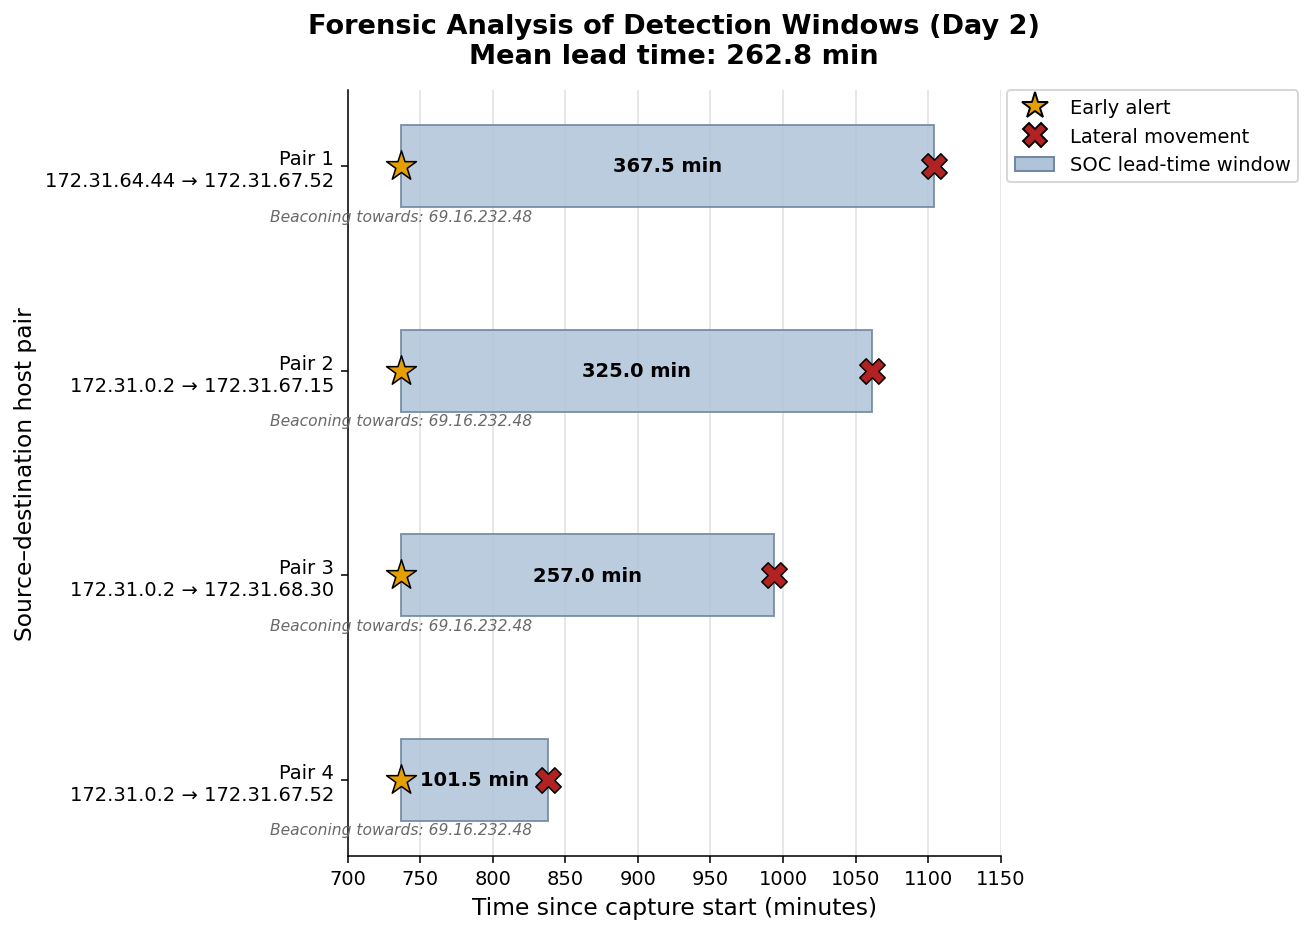

In [ ]:
# =========================================================
# 1. DATA PREP
# =========================================================
df_plot = df_lm_pairs.copy()

# Choose the sorting criterion
# Option A: sort by lateral movement time (largest on top)
df_plot = df_plot.sort_values(by='Lateral_Movement_Min', ascending=False).reset_index(drop=True)

# If we want Pair 1 at the bottom, keep y positions normal and invert the y-axis later.
# Labels in English
y_labels = [
    f"Pair {i+1}\n{row['LM_Source']} → {row['LM_Dest']}"
    for i, row in df_plot.iterrows()
]

avg_lead_time = df_plot['Lead_Time_Min'].mean()

# =========================================================
# 2. FIGURE STYLE
# =========================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans"
})

fig, ax = plt.subplots(figsize=(11.5, 6.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Softer, paper-friendly colors
bar_color = "#AFC4DA"        # muted blue
bar_edge = "#6E86A0"
alert_color = "#E69F00"      # colorblind-friendly orange
lm_color = "#B22222"         # dark red

y_positions = np.arange(len(df_plot))
bar_height = 0.40

# =========================================================
# 3. PLOT ELEMENTS
# =========================================================
# Lead-time window
bars = ax.barh(
    y_positions,
    df_plot["Lead_Time_Min"],
    left=df_plot["First_Alert_Min"],
    height=bar_height,
    color=bar_color,
    edgecolor=bar_edge,
    linewidth=1.0,
    alpha=0.85,
    zorder=2
)

# Early alert marker
ax.scatter(
    df_plot["First_Alert_Min"],
    y_positions,
    color=alert_color,
    edgecolor="black",
    linewidth=0.8,
    marker="*",
    s=260,
    zorder=4
)

# Lateral movement marker
ax.scatter(
    df_plot["Lateral_Movement_Min"],
    y_positions,
    color=lm_color,
    edgecolor="black",
    linewidth=0.8,
    marker="X",
    s=170,
    zorder=4
)

# =========================================================
# 4. ANNOTATIONS
# =========================================================
for i, row in df_plot.iterrows():
    start = row["First_Alert_Min"]
    end = row["Lateral_Movement_Min"]
    lead = row["Lead_Time_Min"]
    center = start + lead / 2

    detalle = row["Forensic_Detail"]

    # Lead time text inside the bar
    ax.text(
        center, y_positions[i],
        f"{lead:.1f} min",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black",
        zorder=5
    )

    # Milestone labels slightly above markers
    # ax.annotate(
    #     "Early alert",
    #     xy=(start, y_positions[i]),
    #     xytext=(0, 16),
    #     textcoords="offset points",
    #     ha="center", va="bottom",
    #     fontsize=9, color=alert_color, fontweight="bold"
    # )

    ax.annotate(
        detalle,
        xy=(start, y_positions[i]),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center", va="top",
        fontsize=8, color="dimgray", style="italic",
        zorder=6
    )

    # ax.annotate(
    #     "Lateral movement",
    #     xy=(end, y_positions[i]),
    #     xytext=(0, 16),
    #     textcoords="offset points",
    #     ha="center", va="bottom",
    #     fontsize=9, color=lm_color, fontweight="bold"
    # )




# =========================================================
# 5. AXES, TICKS, GRID
# =========================================================
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)

ax.set_xlim(700, 1150)
ax.set_xlabel("Time since capture start (minutes)")
ax.set_ylabel("Source–destination host pair")

ax.set_title(
    f"Forensic Analysis of Detection Windows (Day 2)\n"
    f"Mean lead time: {avg_lead_time:.1f} min",
    pad=14,
    fontweight="bold"
)

# If we want Pair 1 at the bottom:
ax.invert_yaxis()

# Tick formatting: t = ...
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"t={int(x)}"))

# Subtle grid for paper
ax.grid(axis="x", color="#D9D9D9", linewidth=0.8, alpha=0.8)
ax.grid(axis="y", visible=False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# 6. LEGEND OUTSIDE THE PLOT
# =========================================================
legend_handles = [
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor=alert_color, markeredgecolor="black",
           markersize=14, label="Early alert"),
    Line2D([0], [0], marker="X", color="w",
           markerfacecolor=lm_color, markeredgecolor="black",
           markersize=12, label="Lateral movement"),
    Patch(facecolor=bar_color, edgecolor=bar_edge,
          label="SOC lead-time window")
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    borderaxespad=0.0
)

# Leave space on the right for the legend
plt.tight_layout(rect=[0, 0, 0.83, 1])

# Best format for paper
# plt.savefig("forensic_detection_windows_day1.pdf", bbox_inches="tight")
# plt.savefig("forensic_detection_windows_day1.png", bbox_inches="tight", dpi=300)

plt.show()

### TTD

In [ ]:
df_mitre_test2 = pd.read_csv("/content/drive/MyDrive/nids-mitre/analysis4paper_entropy/mitre_test2.csv")
df_mitre_test2.head()

,Graph_Window_Idx,Source_IP,Dest_IP,Port_Category,y_real,y_pred,Probability,MITRE_Tactic,MITRE_Tactic_Base
0,20,172.31.66.73,69.16.232.48,DNS,0,1,0.265580,2. Command & Control (Stealth/Web/DNS),Command & Control
1,22,191.101.167.251,24.234.124.9,High Ports / Ephemeral (>= 1024),0,1,0.536945,Unknown Malicious Activity,Unknown
2,1471,172.31.64.8,69.16.232.48,DNS,0,1,0.297543,2. Command & Control (Stealth/Web/DNS),Command & Control
3,1471,172.31.64.8,69.16.232.48,DNS,0,1,0.287135,2. Command & Control (Stealth/Web/DNS),Command & Control
4,1471,172.31.64.8,69.16.232.48,DNS,0,1,0.292808,2. Command & Control (Stealth/Web/DNS),Command & Control


In [ ]:
df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [ ]:
def analyze_timeline(df_real, df_tp, time_window_sec=30, significant_detection_threshold=0.5):
    """
    Reconstructs the attack timeline by calculating the exact Time-To-Detect (TTD)
    and aggregating comprehensive detection statistics per MITRE Tactic.

    Parameters:
    -----------
    df_real : pd.DataFrame
        Ground truth dataframe containing real attack flows (y_real == 1).
    df_tp : pd.DataFrame
        True positive predictions dataframe (y_real == 1 and y_pred == 1).
    time_window_sec : int
        Duration of each graph window in seconds (default is 30).
    significant_detection_threshold : float
        Minimum fraction of real flows detected in a window to consider it a
        'significant' detection for TTD_Strict calculation (default is 0.5).
        NOTE: this is independent from the model's classification threshold,
        which operates at flow level. This one operates at window level.

    Returns:
    --------
    pd.DataFrame
        A detailed timeline dataframe with TTD, span, and detection quality metrics.
    """
    required_real_cols = {'MITRE_Tactic_Base', 'Graph_Window_Idx'}
    required_tp_cols   = {'MITRE_Tactic_Base', 'Graph_Window_Idx', 'Probability'}
    assert required_real_cols.issubset(df_real.columns), \
        f"df_real missing columns: {required_real_cols - set(df_real.columns)}"
    assert required_tp_cols.issubset(df_tp.columns), \
        f"df_tp missing columns: {required_tp_cols - set(df_tp.columns)}"
    assert len(df_tp) == 0 or set(df_tp.index).issubset(set(df_real.index)), \
        "df_tp must be a subset of df_real (shared index). Check that both come from the same split."

    sec_to_min = time_window_sec / 60.0

    real_stats = df_real.groupby('MITRE_Tactic_Base').agg(
        Real_Start_Idx=('Graph_Window_Idx', 'min'),
        Real_Active_Windows=('Graph_Window_Idx', 'nunique')
    ).reset_index()
    total_real_per_tactic = (
        df_real.groupby('MITRE_Tactic_Base').size().reset_index(name='Total_Real_Flows')
    )
    real_stats = real_stats.merge(total_real_per_tactic, on='MITRE_Tactic_Base', how='left')

    tp_stats = df_tp.groupby('MITRE_Tactic_Base').agg(
        First_Detection_Idx=('Graph_Window_Idx', 'min'),
        Last_Detection_Idx=('Graph_Window_Idx', 'max'),
        Total_Alerts=('Graph_Window_Idx', 'count'),
        Active_Windows=('Graph_Window_Idx', 'nunique'),
        Mean_Probability=('Probability', 'mean'),
        Max_Probability=('Probability', 'max')
    ).reset_index()

    timeline_df = pd.merge(real_stats, tp_stats, on='MITRE_Tactic_Base', how='left')
    timeline_df = timeline_df.dropna(subset=['First_Detection_Idx']).copy()
    timeline_df['First_Detection_Idx'] = timeline_df['First_Detection_Idx'].astype(int)
    timeline_df['Last_Detection_Idx']  = timeline_df['Last_Detection_Idx'].astype(int)

    real_per_window = (
        df_real.groupby(['MITRE_Tactic_Base', 'Graph_Window_Idx']).size().reset_index(name='Real_Count')
    )
    tp_per_window = (
        df_tp.groupby(['MITRE_Tactic_Base', 'Graph_Window_Idx']).size().reset_index(name='TP_Count')
    )
    window_detail = pd.merge(real_per_window, tp_per_window,
                             on=['MITRE_Tactic_Base', 'Graph_Window_Idx'], how='left').fillna(0)
    window_detail['Window_Detection_Rate'] = window_detail['TP_Count'] / window_detail['Real_Count']

    first_detection_stats = (
        window_detail
        .merge(timeline_df[['MITRE_Tactic_Base', 'First_Detection_Idx']], on='MITRE_Tactic_Base')
        .query('Graph_Window_Idx == First_Detection_Idx')
        [['MITRE_Tactic_Base', 'Real_Count', 'TP_Count', 'Window_Detection_Rate']]
        .rename(columns={
            'Real_Count': 'First_Detection_Window_Real_Count',
            'TP_Count': 'First_Detection_Window_TP_Count',
            'Window_Detection_Rate': 'First_Detection_Window_Rate'
        })
    )
    timeline_df = timeline_df.merge(first_detection_stats, on='MITRE_Tactic_Base', how='left')

    timeline_df['Tactic_Recall'] = (
        timeline_df['Total_Alerts'] / timeline_df['Total_Real_Flows']
    ).round(4)

    significant_windows = window_detail[
        window_detail['Window_Detection_Rate'] >= significant_detection_threshold
    ]
    ttd_strict = (
        significant_windows.groupby('MITRE_Tactic_Base')['Graph_Window_Idx']
        .min().reset_index().rename(columns={'Graph_Window_Idx': 'First_Significant_Detection_Idx'})
    )
    timeline_df = timeline_df.merge(ttd_strict, on='MITRE_Tactic_Base', how='left')

    timeline_df['Real_Start_Minute']      = timeline_df['Real_Start_Idx']      * sec_to_min
    timeline_df['First_Detection_Minute'] = timeline_df['First_Detection_Idx'] * sec_to_min
    timeline_df['Last_Detection_Minute']  = timeline_df['Last_Detection_Idx']  * sec_to_min
    timeline_df['TTD_Minutes']       = (timeline_df['First_Detection_Minute'] - timeline_df['Real_Start_Minute']).clip(lower=0)
    timeline_df['TTD_Strict_Minutes'] = ((timeline_df['First_Significant_Detection_Idx'] - timeline_df['Real_Start_Idx']) * sec_to_min).clip(lower=0)
    timeline_df['Span_Windows'] = timeline_df['Last_Detection_Idx'] - timeline_df['First_Detection_Idx'] + 1
    timeline_df['Span_Minutes'] = timeline_df['Span_Windows'] * sec_to_min
    timeline_df['Window_Consistency_Pct'] = (
        timeline_df['Active_Windows'] / timeline_df['Real_Active_Windows'] * 100
    ).round(2)
    timeline_df['TTD_Quality'] = pd.cut(
        timeline_df['First_Detection_Window_Rate'],
        bins=[0, 0.25, 0.75, 1.0],
        labels=['Weak (<25%)', 'Partial (25-75%)', 'Strong (>75%)'],
        include_lowest=True
    )

    def classify_ttd(row):
        if row['TTD_Minutes'] > 0 and row['First_Detection_Window_Rate'] >= 0.75:
            return 'Delayed but strong detection'
        elif row['TTD_Minutes'] > 0 and row['First_Detection_Window_Rate'] >= 0.25:
            return 'Delayed partial detection'
        elif row['TTD_Minutes'] > 0:
            return 'Delayed weak detection'
        elif row['First_Detection_Window_Rate'] >= 0.75:
            return 'Immediate strong detection'
        elif row['First_Detection_Window_Rate'] >= 0.25:
            return 'Immediate partial detection'
        else:
            return 'Nominal detection (TTD=0 misleading)'

    timeline_df['TTD_Interpretation'] = timeline_df.apply(classify_ttd, axis=1)
    timeline_df = timeline_df.sort_values('Real_Start_Idx')

    final_columns = [
        'MITRE_Tactic_Base', 'Real_Start_Idx', 'Real_Start_Minute',
        'Real_Active_Windows', 'Total_Real_Flows',
        'First_Detection_Idx', 'Last_Detection_Idx',
        'First_Detection_Minute', 'Last_Detection_Minute',
        'Tactic_Recall', 'Span_Windows', 'Span_Minutes',
        'Active_Windows', 'Window_Consistency_Pct',
        'Total_Alerts', 'Mean_Probability', 'Max_Probability',
        'TTD_Minutes', 'TTD_Strict_Minutes',
        'First_Detection_Window_Real_Count', 'First_Detection_Window_TP_Count',
        'First_Detection_Window_Rate', 'TTD_Quality', 'TTD_Interpretation',
    ]
    return timeline_df[final_columns]


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
ttd_analysis = analyze_timeline(df_gt_day2, df_tp_day2, time_window_sec=30, significant_detection_threshold=0.5)
ttd_analysis

,MITRE_Tactic_Base,Real_Start_Idx,Real_Start_Minute,Real_Active_Windows,Total_Real_Flows,First_Detection_Idx,Last_Detection_Idx,First_Detection_Minute,Last_Detection_Minute,Tactic_Recall,Span_Windows,Span_Minutes,Active_Windows,Window_Consistency_Pct,Total_Alerts,Mean_Probability,Max_Probability,TTD_Minutes,TTD_Strict_Minutes,First_Detection_Window_Real_Count,First_Detection_Window_TP_Count,First_Detection_Window_Rate,TTD_Quality,TTD_Interpretation
0,Command & Control,1473,736.5,750,19320,1473,2585,736.5,1292.5,0.9705,1113,556.5,745,99.33,18750,0.733531,0.824191,0.0,0.0,64,64.0,1.0,Strong (>75%),Immediate strong detection
1,External Malicious Infrastructure Communication,1473,736.5,1001,65547,1473,2600,736.5,1300.0,0.9492,1128,564.0,978,97.70,62216,0.577572,0.962434,0.0,0.0,190,190.0,1.0,Strong (>75%),Immediate strong detection
5,Unknown,1474,737.0,545,7148,1474,2576,737.0,1288.0,0.8727,1103,551.5,533,97.80,6238,0.471490,0.902661,0.0,0.0,6,6.0,1.0,Strong (>75%),Immediate strong detection
2,Initial Access,1483,741.5,428,11042,1483,2580,741.5,1290.0,0.9611,1098,549.0,428,100.00,10612,0.453946,0.954947,0.0,0.0,2,2.0,1.0,Strong (>75%),Immediate strong detection
3,Internal Malicious Activity,1673,836.5,32,94,1673,2347,836.5,1173.5,0.7660,675,337.5,30,93.75,72,0.378291,0.561120,0.0,0.0,2,2.0,1.0,Strong (>75%),Immediate strong detection
4,Lateral Movement,1676,838.0,186,674,1676,2538,838.0,1269.0,0.9941,863,431.5,185,99.46,670,0.457725,0.551670,0.0,0.0,4,4.0,1.0,Strong (>75%),Immediate strong detection


In [ ]:
import torch
import os
from tqdm import tqdm

def verify_entropy_dataset(dataset_path, split='test2', num_categories=7):
    split_path = os.path.join(dataset_path, split)
    files = sorted(
        [f for f in os.listdir(split_path) if f.endswith('.pt')],
        key=lambda x: int(x.split('_')[1].split('.')[0])
    )

    zero_port_edges_total = 0
    node_stats_max_global = 0.0
    node_stats_min_global = float('inf')
    graphs_with_zero_ports = []
    graphs_exceeding_norm  = []
    empty_graphs           = []

    for filename in tqdm(files, desc=f"Verifying {split}"):
        data = torch.load(os.path.join(split_path, filename), weights_only=False)

        # Empty charts — register and skip
        if data.node_stats.numel() == 0 or data.edge_attr.numel() == 0:
            empty_graphs.append(filename)
            continue

        # 1. Edges with unassigned port
        zero_rows = (data.edge_attr[:, 0:num_categories].sum(dim=1) == 0).sum().item()
        if zero_rows > 0:
            zero_port_edges_total += zero_rows
            graphs_with_zero_ports.append((filename, zero_rows))

        # 2. node_stats range
        ns_max = data.node_stats.max().item()
        ns_min = data.node_stats.min().item()
        node_stats_max_global = max(node_stats_max_global, ns_max)
        node_stats_min_global = min(node_stats_min_global, ns_min)

        # 3. Broken normalization
        if ns_max > 1.0:
            graphs_exceeding_norm.append((filename, ns_max))

    print("\n" + "="*55)
    print("ENTROPY DATASET VERIFICATION REPORT")
    print("="*55)
    print(f"Total graphs checked    : {len(files)}")
    print(f"  Empty graphs (skipped): {len(empty_graphs)}")
    print(f"  Non-empty graphs      : {len(files) - len(empty_graphs)}")

    print(f"\n[Port one-hot]")
    print(f"  Edges with no port    : {zero_port_edges_total}")
    print(f"  Affected graphs       : {len(graphs_with_zero_ports)}")
    if graphs_with_zero_ports:
        for fname, count in graphs_with_zero_ports[:5]:
            print(f"    {fname}: {count} edges")
        if len(graphs_with_zero_ports) > 5:
            print(f"    ... and {len(graphs_with_zero_ports)-5} more")

    print(f"\n[node_stats normalization]")
    print(f"  Global min            : {node_stats_min_global:.6f}")
    print(f"  Global max            : {node_stats_max_global:.6f}")
    print(f"  Graphs exceeding 1.0  : {len(graphs_exceeding_norm)}")
    if graphs_exceeding_norm:
        for fname, val in graphs_exceeding_norm[:5]:
            print(f"    {fname}: max={val:.4f}")

    print("="*55)
    ok = (zero_port_edges_total == 0) and (len(graphs_exceeding_norm) == 0)
    print(f"  Status: {'✅ All checks passed' if ok else '❌ Issues found'}")
    print("="*55)


verify_entropy_dataset(
    dataset_path="/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103_entropy",
    split='test2'
)

Verifying test2: 100%|██████████| 2822/2822 [06:16<00:00,  7.49it/s] 


ENTROPY DATASET VERIFICATION REPORT
Total graphs checked    : 2822
  Empty graphs (skipped): 1470
  Non-empty graphs      : 1352

[Port one-hot]
  Edges with no port    : 0
  Affected graphs       : 0

[node_stats normalization]
  Global min            : 0.000000
  Global max            : 0.827087
  Graphs exceeding 1.0  : 0
  Status: ✅ All checks passed


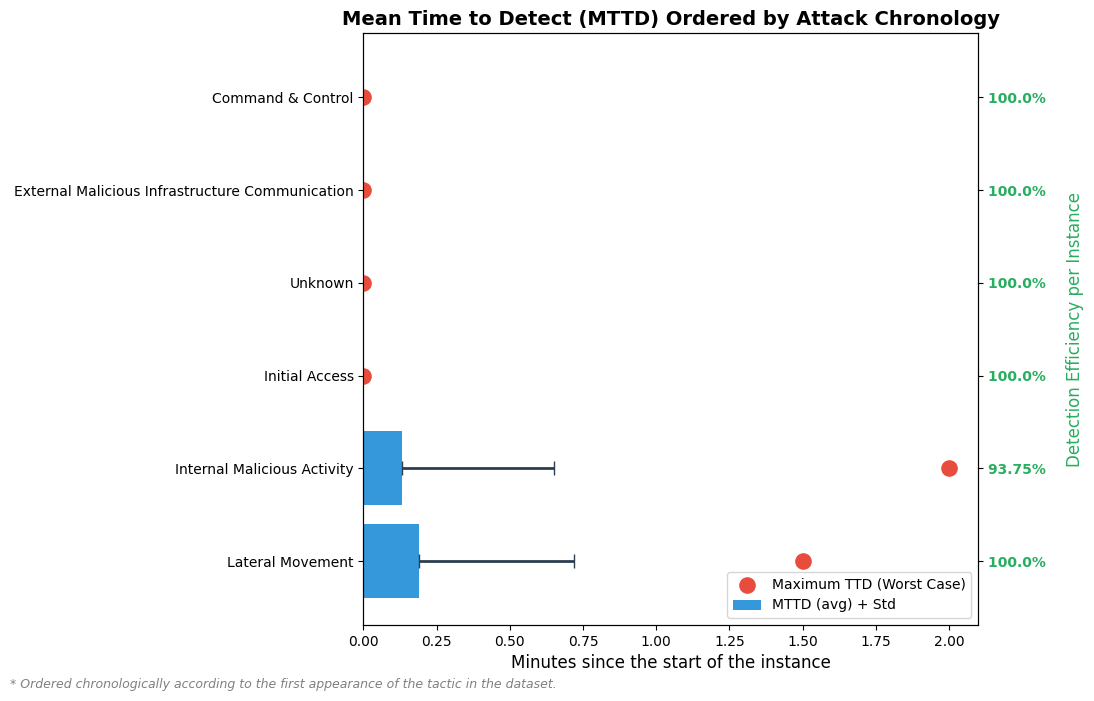

In [ ]:
df_plot = df_mttd.copy()

# ORDER CHRONOLOGICALLY
# Order by the start minute. Ascending=True ensures that the earliest event is index 0
df_plot = df_plot.sort_values(by='Real_Start_Minute', ascending=True).reset_index(drop=True)

# Prepare asymmetric error bars (0 to the left, std to the right)
# The xerr format for skewness is a 2xN array: [left_errors, right_errors]
errores_izq = np.zeros(len(df_plot['MTTD_Minutes'])) # Do not allow bars towards negative times
errores_der = df_plot['Std_TTD_Minutes'].values
errores_asimetricos = [errores_izq, errores_der]


# Figure
fig, ax1 = plt.subplots(figsize=(11, 7))

y_pos = np.arange(len(df_plot['MITRE_Tactic_Base']))

# Axis 1: MTTD (Bars with error bars)
bars = ax1.barh(y_pos, df_plot['MTTD_Minutes'], xerr=errores_asimetricos,
                color='#3498db', capsize=5, ecolor='#2c3e50', error_kw={'elinewidth': 2},
                label='MTTD (avg) + Std')

# Red mark (scatter) for the Maximum TTD
ax1.scatter(df_plot['Max_TTD_Minutes'], y_pos, color='#e74c3c', s=120, zorder=5,
            label='Maximum TTD (Worst Case)')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_plot['MITRE_Tactic_Base'], fontsize=10)
ax1.invert_yaxis()  # Invest so that the first chronological tactic is at the top
ax1.set_xlabel('Minutes since the start of the instance', fontsize=12)
ax1.set_title('Mean Time to Detect (MTTD) Ordered by Attack Chronology', fontsize=14, fontweight='bold')

# # Value texts above the bars (adjusted so as not to overlap with the standard)
# for i, bar in enumerate(bars):
#     mttd_val = df_plot['MTTD'].iloc[i]
#     std_val = df_plot['Std_TTD'].iloc[i]
#     max_val = df_plot['Max_TTD'].iloc[i]

#     # Position the text to the right of the error bar
#     x_pos = mttd_val + std_val + 0.05
#     ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{mttd_val} min',
#              va='center', color='#2980b9', fontweight='bold', fontsize=10)

# # Value texts above the bars (now including ± std)
# for i, bar in enumerate(bars):
#     mttd_val = df_plot['MTTD_Minutes'].iloc[i]
#     std_val = df_plot['Std_TTD_Minutes'].iloc[i]

#     text_label = f'{mttd_val} ± {std_val} min'

#     # Position the text to the right of the error bar
#     x_pos = mttd_val + std_val + 0.05
#     ax1.text(x_pos, bar.get_y() + bar.get_height()/2, text_label,
#              va='center', color='#2980b9', fontweight='bold', fontsize=10)

# Axis 2: Detection Rate (Text on the right)
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{rate}%   " for rate in df_plot['Instance_Detection_Rate_%']], color='#27ae60', fontweight='bold')
ax2.set_ylabel('Detection Efficiency per Instance', color='#27ae60', fontsize=12)

# Add an explanatory note about the order
fig.text(0.01, 0.01, '* Ordered chronologically according to the first appearance of the tactic in the dataset.',
         fontsize=9, style='italic', color='gray')

ax1.legend(loc='lower right')
plt.tight_layout()

plt.subplots_adjust(bottom=0.1)
plt.show()

# Some checks

These 6 cells are dataset audit and integrity tools. The pipeline builds temporary graphs (30-second snapshots) saved as .pt files. The cells verify that these files are correctly assigned to their splits (train/val/test) and that the numbers match the original CSV.

## Graphs

In [ ]:
import os
import torch
import pandas as pd
from collections import defaultdict

ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_entropy"
SPLITS = ["train", "val", "test"]

def summarize_split(root_path, split_name):
    """
    It iterates through all the .pt files in a split and produces a complete statistical summary:
    - Number of snapshots (including empty ones and their proportion)
    - Total flows/edges, broken down into attack vs. benign
    - Positive class rate (positive_rate)
    - Global unique nodes across the split
    - Time range (first and last timestamp)
    - Imbalance ratio (benign/attack)
   """

    split_dir = os.path.join(root_path, split_name)
    files = sorted(
        [f for f in os.listdir(split_dir) if f.endswith(".pt")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )

    total_graphs = 0
    empty_graphs = 0
    total_edges = 0
    total_nodes_occurrences = 0
    unique_global_nodes = set()

    benign_edges = 0
    attack_edges = 0

    timestamps = []

    for fname in files:
        data = torch.load(os.path.join(split_dir, fname), weights_only=False)

        total_graphs += 1

        num_edges = int(data.edge_attr.size(0)) if hasattr(data, "edge_attr") else 0
        num_nodes = int(data.num_nodes) if hasattr(data, "num_nodes") else 0

        total_edges += num_edges
        total_nodes_occurrences += num_nodes

        if num_edges == 0:
            empty_graphs += 1

        if hasattr(data, "global_node_ids"):
            unique_global_nodes.update(data.global_node_ids.tolist())

        if hasattr(data, "y") and data.y is not None and len(data.y) > 0:
            y = data.y.view(-1).cpu()
            attack_edges += int((y == 1).sum().item())
            benign_edges += int((y == 0).sum().item())

        if hasattr(data, "timestamp"):
            timestamps.append(pd.to_datetime(str(data.timestamp)))

    pos_rate = attack_edges / total_edges if total_edges > 0 else 0.0

    summary = {
        "split": split_name,
        "num_snapshots": total_graphs,
        "num_empty_snapshots": empty_graphs,
        "empty_snapshot_ratio": empty_graphs / total_graphs if total_graphs > 0 else 0.0,
        "num_edges_flows": total_edges,
        "num_attack_flows": attack_edges,
        "num_benign_flows": benign_edges,
        "positive_rate": pos_rate,
        "num_node_occurrences": total_nodes_occurrences,
        "num_unique_global_nodes": len(unique_global_nodes),
        "start_time": min(timestamps) if timestamps else None,
        "end_time": max(timestamps) if timestamps else None,
    }
    return summary

rows = []
for split in SPLITS:
    rows.append(summarize_split(ROOT_PATH, split))

ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103_entropy"
SPLITS = ["test2"]
for split in SPLITS:
    rows.append(summarize_split(ROOT_PATH, split))


df_summary = pd.DataFrame(rows)


df_summary["imbalance_ratio_benign_over_attack"] = df_summary.apply(
    lambda row: (row["num_benign_flows"] / row["num_attack_flows"])
    if row["num_attack_flows"] > 0 else float("inf"),
    axis=1
)

print(df_summary.to_string(index=False))

split  num_snapshots  num_empty_snapshots  empty_snapshot_ratio  num_edges_flows  num_attack_flows  num_benign_flows  positive_rate  num_node_occurrences  num_unique_global_nodes              start_time                end_time  imbalance_ratio_benign_over_attack
train           1998                 1237              0.619119          1041793             49564            992229       0.047576                254487                    25413 2018-02-28 00:12:55.854 2018-02-28 16:51:25.854                           20.019147
  val            428                    0              0.000000           788535             31329            757206       0.039731                189446                    18092 2018-02-28 16:51:55.854 2018-02-28 20:25:25.854                           24.169492
 test            429                    0              0.000000           191679              3434            188245       0.017915                 55564                     7741 2018-02-28 20:25:55.854 2018-02-

In [ ]:
import os
import torch
import pandas as pd

ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_entropy"
SPLITS = ["train", "val", "test"]

def snapshot_time_range(root_path, split):
    """
    It loads the timestamps of each .pt file and returns the first and last
    timestamps of the split.

    Note: It's a quick verification that the splits cover the expected time ranges for
    the day (Wednesday/Thursday).
    """
    split_dir = os.path.join(root_path, split)
    files = sorted(
        [f for f in os.listdir(split_dir) if f.endswith(".pt")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )

    timestamps = []
    for fname in files:
        data = torch.load(os.path.join(split_dir, fname), weights_only=False)
        timestamps.append(pd.to_datetime(str(data.timestamp)))

    return {
        "split": split,
        "num_snapshots": len(timestamps),
        "first_snapshot_time": min(timestamps) if timestamps else None,
        "last_snapshot_time": max(timestamps) if timestamps else None,
    }

for split in SPLITS:
    print(snapshot_time_range(ROOT_PATH, split))

ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103_entropy"
SPLITS = ["test2"]
for split in SPLITS:
    print(snapshot_time_range(ROOT_PATH, split))

{'split': 'train', 'num_snapshots': 1998, 'first_snapshot_time': Timestamp('2018-02-28 00:12:55.854000'), 'last_snapshot_time': Timestamp('2018-02-28 16:51:25.854000')}
{'split': 'val', 'num_snapshots': 428, 'first_snapshot_time': Timestamp('2018-02-28 16:51:55.854000'), 'last_snapshot_time': Timestamp('2018-02-28 20:25:25.854000')}
{'split': 'test', 'num_snapshots': 429, 'first_snapshot_time': Timestamp('2018-02-28 20:25:55.854000'), 'last_snapshot_time': Timestamp('2018-02-28 23:59:55.854000')}
{'split': 'test2', 'num_snapshots': 2822, 'first_snapshot_time': Timestamp('2018-03-01 00:00:03.289000'), 'last_snapshot_time': Timestamp('2018-03-01 23:30:33.289000')}


## Flows

In [ ]:
"""
Reconstructing split limits (without a named function)
Load the original CSV (cicids2018v3_wed2802.csv) and recalculate the same time limits
used by the original pipeline:

- 70% of the day → LIMIT_TRAIN
- 85% of the day → LIMIT_VAL
- The remainder → test1

Note: It establishes the baseline "true" to validate that the .pt files were correctly allocated.
"""

CSV_PATH = "/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/cicids2018v3_wed2802.csv"
df = pd.read_csv(CSV_PATH)

df["FLOW_START_TIME"] = pd.to_datetime(df["FLOW_START_TIME"])


mask_valid_ips = (df["IPV4_SRC_ADDR"] != "0.0.0.0") & (df["IPV4_DST_ADDR"] != "0.0.0.0")
df = df[mask_valid_ips].copy()

GLOBAL_START_TIME = df["FLOW_START_TIME"].min()
GLOBAL_END_TIME = df["FLOW_START_TIME"].max()
TOTAL_DURATION = GLOBAL_END_TIME - GLOBAL_START_TIME

LIMIT_TRAIN = GLOBAL_START_TIME + (TOTAL_DURATION * 0.70)
LIMIT_VAL = GLOBAL_START_TIME + (TOTAL_DURATION * 0.85)

train_df = df[df["FLOW_START_TIME"] < LIMIT_TRAIN]
val_df   = df[(df["FLOW_START_TIME"] >= LIMIT_TRAIN) & (df["FLOW_START_TIME"] < LIMIT_VAL)]
test1_df = df[df["FLOW_START_TIME"] >= LIMIT_VAL]

for name, part in [("train", train_df), ("val", val_df), ("test1", test1_df)]:
    print(
        name,
        "count=", len(part),
        "min=", part["FLOW_START_TIME"].min(),
        "max=", part["FLOW_START_TIME"].max()
    )

print("GLOBAL_START_TIME =", GLOBAL_START_TIME)
print("GLOBAL_END_TIME   =", GLOBAL_END_TIME)
print("LIMIT_TRAIN       =", LIMIT_TRAIN)
print("LIMIT_VAL         =", LIMIT_VAL)

train count= 1041645 min= 2018-02-28 00:12:55.854000 max= 2018-02-28 16:51:52.280000
val count= 788681 min= 2018-02-28 16:51:52.324000 max= 2018-02-28 20:25:55.790000
test1 count= 191681 min= 2018-02-28 20:25:55.825000 max= 2018-02-28 23:59:59.321000
GLOBAL_START_TIME = 2018-02-28 00:12:55.854000
GLOBAL_END_TIME   = 2018-02-28 23:59:59.321000
LIMIT_TRAIN       = 2018-02-28 16:51:52.280900
LIMIT_VAL         = 2018-02-28 20:25:55.800950


In [ ]:
"""
Same as previous cell, but for test2 (day 2)
"""

CSV_PATH_TEST2 = "/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/cicids2018v3_thu0103.csv"
df2 = pd.read_csv(CSV_PATH_TEST2)
df2["FLOW_START_TIME"] = pd.to_datetime(df2["FLOW_START_TIME"])

mask_valid_ips = (df2["IPV4_SRC_ADDR"] != "0.0.0.0") & (df2["IPV4_DST_ADDR"] != "0.0.0.0")
df2 = df2[mask_valid_ips].copy()

print("test2_count =", len(df2))
print("test2_min   =", df2["FLOW_START_TIME"].min())
print("test2_max   =", df2["FLOW_START_TIME"].max())

test2_count = 2135957
test2_min   = 2018-03-01 00:00:03.289000
test2_max   = 2018-03-01 23:30:54.233000


## Check split

In [ ]:
import os
import torch
import pandas as pd

ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_entropy"
SPLITS = ["train", "val", "test"]


wed = pd.read_csv("/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/cicids2018v3_wed2802.csv")
wed["FLOW_START_TIME"] = pd.to_datetime(wed["FLOW_START_TIME"])
wed = wed[(wed["IPV4_SRC_ADDR"] != "0.0.0.0") & (wed["IPV4_DST_ADDR"] != "0.0.0.0")].copy()

GLOBAL_START_TIME = wed["FLOW_START_TIME"].min()
GLOBAL_END_TIME = wed["FLOW_START_TIME"].max()
TOTAL_DURATION = GLOBAL_END_TIME - GLOBAL_START_TIME
LIMIT_TRAIN = GLOBAL_START_TIME + (TOTAL_DURATION * 0.70)
LIMIT_VAL = GLOBAL_START_TIME + (TOTAL_DURATION * 0.85)

def check_split(split):
    """
    Cross-reference the timestamps of each .pt file with the limits calculated earlier
    For each file, check if its timestamp falls within the correct range for its split.
    Report any "bad" files that are out of place.

    Note: This is the most critical integrity validation. If a snapshot of a late-night attack fell into
    the training split due to an allocation error, the model would "see the future" during training
    (temporal data leakage).
    """
    split_dir = os.path.join(ROOT_PATH, split)
    files = sorted(
        [f for f in os.listdir(split_dir) if f.endswith(".pt")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )

    bad = []
    for fname in files:
        data = torch.load(os.path.join(split_dir, fname), weights_only=False)
        ts = pd.to_datetime(str(data.timestamp))

        if split == "train" and not (ts < LIMIT_TRAIN):
            bad.append((fname, ts))
        elif split == "val" and not (LIMIT_TRAIN <= ts < LIMIT_VAL):
            bad.append((fname, ts))
        elif split == "test" and not (ts >= LIMIT_VAL):
            bad.append((fname, ts))

    return bad

for split in ["train", "val", "test"]:
    bad = check_split(split)
    print(split, "bad_count =", len(bad))
    if bad[:5]:
        print("examples:", bad[:5])

train bad_count = 0
val bad_count = 0
test bad_count = 0


In [ ]:
"""
Recalculate the exact same window_id and window_start_time from the raw CSV file
as the original pipeline (30-second windows starting from GLOBAL_START_TIME).

Assign each flow to train/val/test1 based on its window's window_start_time (not the individual flow's)
and display the count per split.

Note: Split assignment is done per entire window, not per flow. This ensures that all flows within
the same timeline graph go to the same split. This cell verifies that this logic was followed.
"""

CSV_PATH = "/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/cicids2018v3_wed2802.csv"

TIME_WINDOW_SEC = 30

df = pd.read_csv(CSV_PATH)
df["FLOW_START_TIME"] = pd.to_datetime(df["FLOW_START_TIME"])


mask_valid_ips = (df["IPV4_SRC_ADDR"] != "0.0.0.0") & (df["IPV4_DST_ADDR"] != "0.0.0.0")
df = df[mask_valid_ips].copy()

GLOBAL_START_TIME = df["FLOW_START_TIME"].min()
GLOBAL_END_TIME = df["FLOW_START_TIME"].max()
TOTAL_DURATION = GLOBAL_END_TIME - GLOBAL_START_TIME

LIMIT_TRAIN = GLOBAL_START_TIME + (TOTAL_DURATION * 0.70)
LIMIT_VAL = GLOBAL_START_TIME + (TOTAL_DURATION * 0.85)

# rebuild window_id just like in the pipeline
df["window_id"] = ((df["FLOW_START_TIME"] - GLOBAL_START_TIME) // pd.Timedelta(seconds=TIME_WINDOW_SEC)).astype(int)
df["window_start_time"] = GLOBAL_START_TIME + pd.to_timedelta(df["window_id"] * TIME_WINDOW_SEC, unit="s")

def assign_split_from_window_start(ts):
    if ts < LIMIT_TRAIN:
        return "train"
    elif ts < LIMIT_VAL:
        return "val"
    else:
        return "test1"

df["split_by_window"] = df["window_start_time"].apply(assign_split_from_window_start)

summary = df.groupby("split_by_window").size()
print(summary)


for split, g in df.groupby("split_by_window"):
    print("\n", split)
    print("flow count         =", len(g))
    print("flow min/max       =", g["FLOW_START_TIME"].min(), g["FLOW_START_TIME"].max())
    print("window start min/max =", g["window_start_time"].min(), g["window_start_time"].max())

split_by_window
test1     191679
train    1041793
val       788535
dtype: int64

 test1
flow count         = 191679
flow min/max       = 2018-02-28 20:25:55.862000 2018-02-28 23:59:59.321000
window start min/max = 2018-02-28 20:25:55.854000 2018-02-28 23:59:55.854000

 train
flow count         = 1041793
flow min/max       = 2018-02-28 00:12:55.854000 2018-02-28 16:51:55.843000
window start min/max = 2018-02-28 00:12:55.854000 2018-02-28 16:51:25.854000

 val
flow count         = 788535
flow min/max       = 2018-02-28 16:51:55.892000 2018-02-28 20:25:55.828000
window start min/max = 2018-02-28 16:51:55.854000 2018-02-28 20:25:25.854000
